# 붓꽃 데이터 분석

## 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns # 시본

## 붓꽃(아이리스) 데이터 불러오기

In [2]:
iris = sns.load_dataset('iris')

In [3]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [5]:
# 기초통계량

iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
# 품종
iris['species']

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: str

In [7]:
# 품목별 데이터 개수
iris['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [8]:
# count 이름의 데이터프레임
count = pd.DataFrame(iris['species'].value_counts())

In [9]:
count

,count
species,
setosa,50
versicolor,50
virginica,50


## 결측지 확인

In [10]:
iris.isnull()

,sepal_length,sepal_width,petal_length,petal_width,species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [11]:
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

## 중복데이터 확인

In [12]:
iris.duplicated().sum()

np.int64(1)

In [13]:
index = iris.duplicated()
index.head()

0    False
1    False
2    False
3    False
4    False
dtype: bool

### loc[행, 열]

In [14]:
iris.loc[index, :]

,sepal_length,sepal_width,petal_length,petal_width,species
142,5.8,2.7,5.1,1.9,virginica


In [15]:
result = (iris['sepal_length'] == 5.8) & (iris['petal_width'] == 1.9)
iris.loc[result, :]

,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


### 중복데이터 삭제 --> drop_duplicates()

In [16]:
iris.drop_duplicates()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [17]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [18]:
iris.loc[result, :]

,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


## 데이터그룹핑

In [19]:
iris.groupby('species').sum()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,329.4,148.7,277.6,101.3


In [ ]:
iris.groupby('species').mean() # 평균

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


# 붓꽃 데이터 시각화

In [21]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 꽃받침의 길이 시각화 - 막대그래프

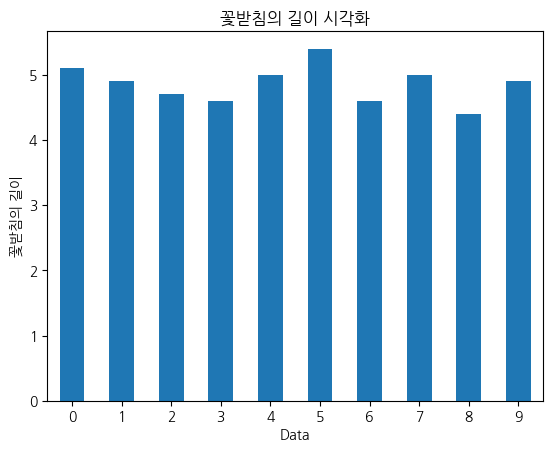

In [22]:
iris.sepal_length[:10].plot(kind='bar', rot=0) # 10개의 데이터만 막대그래프, 회전 0도
plt.title('꽃받침의 길이 시각화') # 차트 제목
plt.xlabel('Data') # x축 제목
plt.ylabel('꽃받침의 길이') # y축 제목
plt.show() # 깔끔하게 하려면

## 붓꽃의 품종별 그룹화 - 평균 - 새로운 데이터프레임으로 저장 - 차트 생성

In [23]:
df2 = iris.groupby(iris['species']).mean()
df2

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


### 품종별 꽃받침 길이 그래프

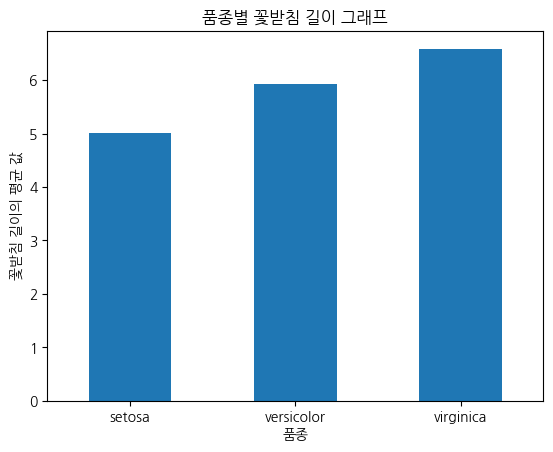

In [24]:
df2.sepal_length[:].plot(kind='bar', rot=0)
plt.title('품종별 꽃받침 길이 그래프')
plt.xlabel('품종')
plt.ylabel('꽃받침 길이의 평균 값')
plt.show()

## 히스토그램 (빈도수 그래프)

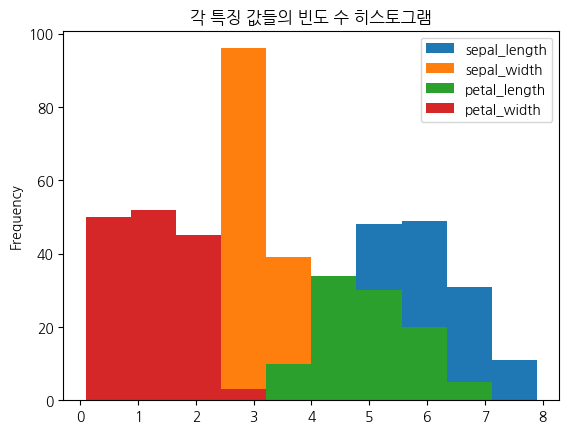

In [25]:
iris.plot(kind='hist')
plt.title('각 특징 값들의 빈도 수 히스토그램')
plt.show()

## 상자 그래프 --> 이상치 발견

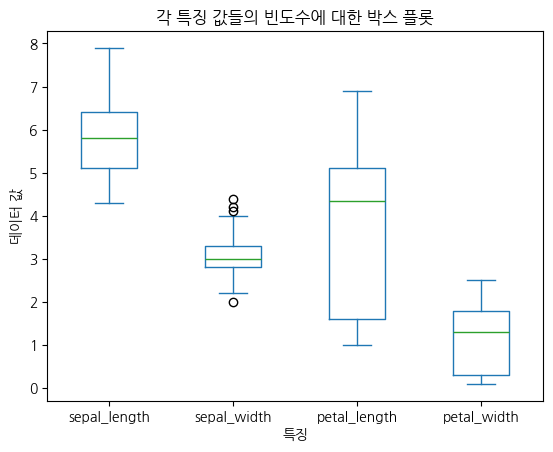

In [26]:
iris.plot(kind='box')
plt.title('각 특징 값들의 빈도수에 대한 박스 플롯')
plt.xlabel('특징')
plt.ylabel('데이터 값')
plt.show()

## 산점도 그래프 (산포그래프)

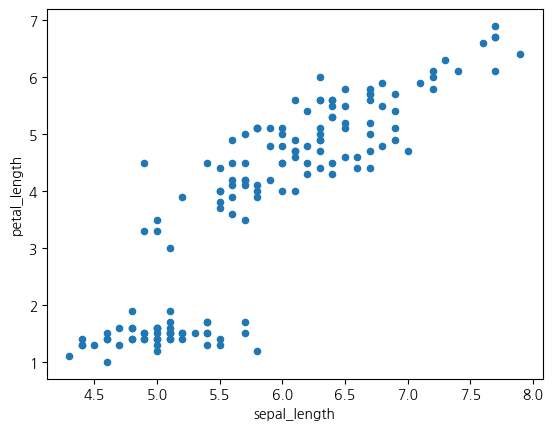

In [27]:
iris.plot(x='sepal_length', y='petal_length', kind='scatter')
plt.show()

### 연습문제 1번

In [41]:
iris1 = iris = sns.load_dataset('iris')
iris1.groupby('species').max() # 최댓값

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.8,4.4,1.9,0.6
versicolor,7.0,3.4,5.1,1.8
virginica,7.9,3.8,6.9,2.5


In [42]:
iris1.groupby('species').min() # 최솟값

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,4.3,2.3,1.0,0.1
versicolor,4.9,2.0,3.0,1.0
virginica,4.9,2.2,4.5,1.4


In [43]:
iris1 = iris.rename(columns={'sepal_length':"SL", 'sepal_width':'SW', 'petal_length':'PL', 'petal_width':"PW", 'species':'SP'})
iris1.head()

,SL,SW,PL,PW,SP
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 연습문제 2번

In [ ]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# total_bill, tip -> 오름차순 -> 상위 10개
tips.sort_values(['total_bill','tip']).head(10)

,total_bill,tip,sex,smoker,day,time,size
67,3.07,1.00,Female,Yes,Sat,Dinner,1
92,5.75,1.00,Female,Yes,Fri,Dinner,2
111,7.25,1.00,Female,No,Sat,Dinner,1
172,7.25,5.15,Male,Yes,Sun,Dinner,2
149,7.51,2.00,Male,No,Thur,Lunch,2
195,7.56,1.44,Male,No,Thur,Lunch,2
218,7.74,1.44,Male,Yes,Sat,Dinner,2
145,8.35,1.50,Female,No,Thur,Lunch,2
135,8.51,1.25,Female,No,Thur,Lunch,2
126,8.52,1.48,Male,No,Thur,Lunch,2


In [ ]:
# size --> 내림차순, tip --> 오름차순 --> 상위 10개만
tips.sort_values(['size', 'tip'], ascending=[False,True]).head(10)

,total_bill,tip,sex,smoker,day,time,size
125,29.80,4.20,Female,No,Thur,Lunch,6
143,27.05,5.00,Female,No,Thur,Lunch,6
156,48.17,5.00,Male,No,Sun,Dinner,6
141,34.30,6.70,Male,No,Thur,Lunch,6
187,30.46,2.00,Male,Yes,Sun,Dinner,5
216,28.15,3.00,Male,Yes,Sat,Dinner,5
142,41.19,5.00,Male,No,Thur,Lunch,5
185,20.69,5.00,Male,No,Sun,Dinner,5
155,29.85,5.14,Female,No,Sun,Dinner,5
153,24.55,2.00,Male,No,Sun,Dinner,4


연습문제 3번

In [ ]:
iris.sort_values('sepal_width', ascending=False) # 내림차순 정렬

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,setosa
33,5.5,4.2,1.4,0.2,setosa
32,5.2,4.1,1.5,0.1,setosa
14,5.8,4.0,1.2,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
...,...,...,...,...,...
53,5.5,2.3,4.0,1.3,versicolor
62,6.0,2.2,4.0,1.0,versicolor
68,6.2,2.2,4.5,1.5,versicolor
119,6.0,2.2,5.0,1.5,virginica


In [46]:
iris2 = iris.sort_values('sepal_width', ascending=False).head(10)
iris2

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,setosa
33,5.5,4.2,1.4,0.2,setosa
32,5.2,4.1,1.5,0.1,setosa
14,5.8,4.0,1.2,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
16,5.4,3.9,1.3,0.4,setosa
44,5.1,3.8,1.9,0.4,setosa
46,5.1,3.8,1.6,0.2,setosa
117,7.7,3.8,6.7,2.2,virginica
131,7.9,3.8,6.4,2.0,virginica


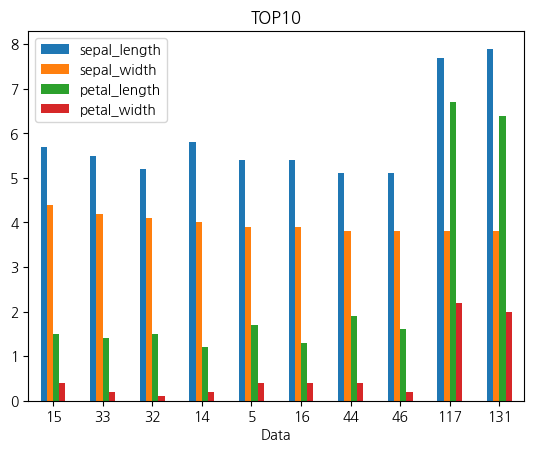

In [47]:
# 막대그래프
iris2.plot(kind='bar', rot=0)
plt.title('TOP10')
plt.xlabel('Data')
plt.show()

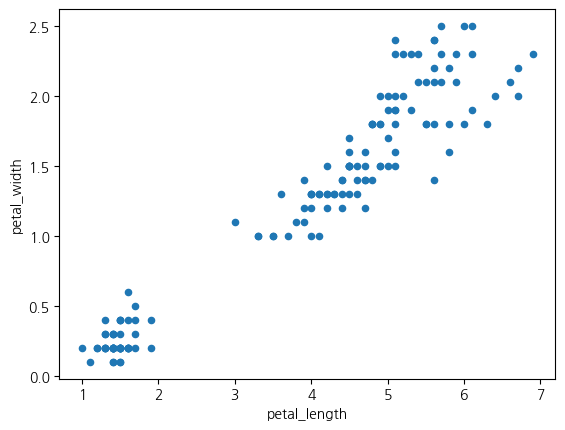

In [48]:
# x축 -> 꽃잎의 길이
# y축 -> 꽃잎의 너비
iris.plot(kind='scatter', x='petal_length', y='petal_width')
plt.show()

## 연습문제 4번

### 1) 성별에 따른 생존율

In [50]:
titanic = pd.read_csv('train.csv')
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
titanic_2 = titanic[['Sex', 'Survived']] # 성별, 생존율
titanic_2

,Sex,Survived
0,male,0
1,female,1
2,female,1
3,female,1
4,male,0
...,...,...
886,male,0
887,female,1
888,female,0
889,male,1


In [ ]:
titanic_2.groupby('Sex').mean() # 성별에 따른 생존율 평균

,Survived
Sex,
female,0.742038
male,0.188908


In [55]:
# 함께 승선한 부모와 자식 수 (Parch)에 따른 생존율
titanic_3 = titanic[['Parch', 'Survived']]
titanic_3

,Parch,Survived
0,0,0
1,0,1
2,0,1
3,0,1
4,0,0
...,...,...
886,0,0
887,0,1
888,2,0
889,0,1


In [ ]:
titanic_3.groupby('Parch').mean().sort_values('Survived', ascending=False)

,Survived
Parch,
3,0.600000
1,0.550847
2,0.500000
0,0.343658
5,0.200000
4,0.000000
6,0.000000


In [ ]:
titanic_3.groupby('Parch', as_index=False).mean().sort_values('Survived', ascending=False) # 생존율에 따른 내림차순
# as_index=False = 앞에 숫자 나오게 하기

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


In [60]:
# 객실 등급(Pclass), 성별(Sex) 컬럼별로 생존율, 나이의 평균값
# 그룹 --> 2개
# 평균값 --> 2개

titanic_4 = titanic[['Pclass', 'Sex', 'Survived', 'Age']]
titanic_4

,Pclass,Sex,Survived,Age
0,3,male,0,22.0
1,1,female,1,38.0
2,3,female,1,26.0
3,1,female,1,35.0
4,3,male,0,35.0
...,...,...,...,...
886,2,male,0,27.0
887,1,female,1,19.0
888,3,female,0,NaN
889,1,male,1,26.0


In [61]:
titanic_4.groupby(['Pclass', 'Sex']).mean()

Survived        Age
Pclass Sex                        
1      female  0.968085  34.611765
       male    0.368852  41.281386
2      female  0.921053  28.722973
       male    0.157407  30.740707
3      female  0.500000  21.750000
       male    0.135447  26.507589

#### 데이터프레임명.groupby(['그룹할컬럼1','그룹할컬럼2'])[['계산하고 싶은 컬럼1','계산하고 싶은 컬럼2']].mean()

In [64]:
titanic.groupby(['Pclass','Sex'])[['Survived','Age']].mean()

Survived        Age
Pclass Sex                        
1      female  0.968085  34.611765
       male    0.368852  41.281386
2      female  0.921053  28.722973
       male    0.157407  30.740707
3      female  0.500000  21.750000
       male    0.135447  26.507589

In [65]:
# 항구별 생존자
titanic_5 = titanic[['Embarked', 'Survived']]
titanic_5

,Embarked,Survived
0,S,0
1,C,1
2,S,1
3,S,1
4,S,0
...,...,...
886,S,0
887,S,1
888,S,0
889,C,1


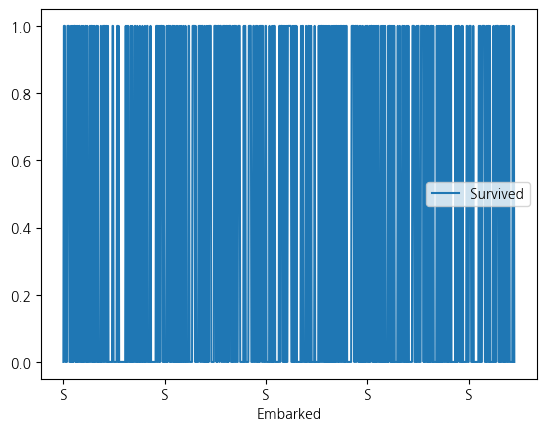

In [66]:
titanic_5.plot(kind='line', x='Embarked', y='Survived')
plt.show()

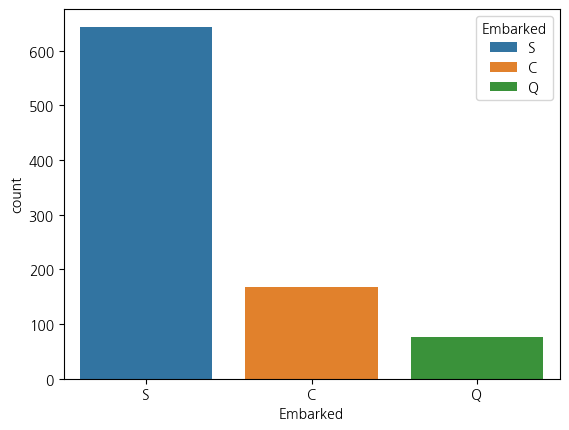

In [70]:
# seabron 사용 --> 생존자 --> 건수 --> countplot()
sns.countplot(data=titanic_5, x='Embarked', hue='Embarked')
plt.show()

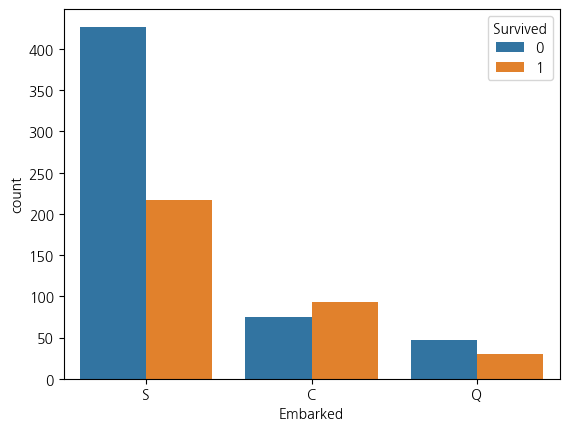

In [71]:
sns.countplot(data=titanic_5, x='Embarked', hue='Survived')
plt.show()